 NLP Final Term Project -- Full-Dataset Demo NotebookGroup 02, Section BThis notebook reproduces the project's full-dataset results in minutes rather thanthe ~9 hours the original training took, by using the saved model checkpoints for**inference** instead of retraining from scratch.**What runs live in this notebook (genuine computation, not cached numbers):**- Classical baselines (Naive Bayes, Logistic Regression, SVM) -- refit from scratch,  ~15 seconds total.- BERT and DeBERTa's Table 2 rows -- the saved winning checkpoints are loaded and run  through the test set via forward-pass inference (no training, no gradients), which  reproduces their exact reported metrics in about a minute per model.- The ensemble, confusion matrices, and both final tables -- all computed live from  the above.**What is loaded from disk rather than recomputed here:** Table 1 has 32 hyperparameterconfigurations, but only the 4 *winning* configurations had their model weights saved(saving all 32 would be roughly 18 GB of checkpoints, not done). The other 28 rows ofTable 1 were genuinely produced by real training runs during the original ~9-hoursweep -- they are read from the saved result files here rather than retrained, becauseretraining them would take the original 9 hours again, not 5 minutes. This is statedexplicitly rather than left implicit.

## Section 0 -- Setup

In [1]:
import os
os.environ.setdefault('HF_HOME', '/media/filwel/MLProject1/hf_cache')
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'true')

import gc, json, re, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

PS = Path('/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final/paper_scale')
WORK, RESULTS, PROBS, MODELS = PS/'work', PS/'results', PS/'probs', PS/'models'
OUT = Path('/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final/demo_full_dataset')
FIG = OUT / 'figures'; FIG.mkdir(exist_ok=True)

print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device:', torch.cuda.get_device_name(0))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

t_notebook_start = time.time()

torch 2.11.0+cu128 | cuda available: True
device: NVIDIA GeForce RTX 3060 Ti


## Section 1 -- Load the full-dataset, duplicate-aware splitThese files were built once from the raw `daigt.csv` / `hc3.jsonl` and are loadedhere rather than rebuilt, so this section is instant.

In [2]:
def load_split(tag):
    df = pd.read_parquet(WORK / f'data_{tag}.parquet')
    sp = np.load(WORK / f'split_{tag}.npz')
    return df, {'train': sp['train'], 'val': sp['val'], 'test': sp['test']}

DATA, SPLITS = {}, {}
for tag in ('D1', 'D2'):
    DATA[tag], SPLITS[tag] = load_split(tag)
    s = SPLITS[tag]
    print('%s: train=%d val=%d test=%d (test class balance: %s)' % (
        tag, len(s['train']), len(s['val']), len(s['test']),
        DATA[tag].loc[s['test'], 'label'].value_counts().sort_index().to_dict()))

D1: train=25196 val=2800 test=6998 (test class balance: {0: 3519, 1: 3479})
D2: train=38785 val=4289 test=10732 (test class balance: {0: 5377, 1: 5355})


 Section 2 -- Classical baselines, refit liveNaive Bayes and Logistic Regression on Bag-of-Words, Support Vector Machine onTF-IDF -- identical preprocessing and model choices as the midterm, applied to thefull-dataset split. This genuinely retrains in well under a minute.

In [3]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

for pkg, path in (('punkt','tokenizers/punkt'), ('punkt_tab','tokenizers/punkt_tab'),
                  ('stopwords','corpora/stopwords'), ('wordnet','corpora/wordnet'), ('omw-1.4','corpora/omw-1.4')):
    try: nltk.data.find(path)
    except LookupError: nltk.download(pkg, quiet=True)

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = re.sub(r'[^a-z\s]', ' ', str(text).lower())
    tokens = word_tokenize(text)
    return ' '.join(t for t in (lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 1))

def weighted_metrics(y, p):
    a = accuracy_score(y, p)
    pr, rc, f, _ = precision_recall_fscore_support(y, p, average='weighted', zero_division=0)
    return round(a,4), round(pr,4), round(rc,4), round(f,4)

CLASSICAL_SPECS = (
    ('Naive Bayes', 'BoW', CountVectorizer, lambda: MultinomialNB()),
    ('Logistic Regression', 'BoW', CountVectorizer, lambda: LogisticRegression(max_iter=1000)),
    ('Support Vector Machine', 'TF-IDF', TfidfVectorizer, lambda: LinearSVC()),
)

CLASSICAL_RESULTS = {}
t0 = time.time()
for tag in ('D1', 'D2'):
    df, sp = DATA[tag], SPLITS[tag]
    clean = df['text'].apply(preprocess)
    ytr, yte = df.loc[sp['train'],'label'].values, df.loc[sp['test'],'label'].values
    Xtr_text, Xte_text = clean.loc[sp['train']], clean.loc[sp['test']]
    for name, rep, Vec, build in CLASSICAL_SPECS:
        vec = Vec(); Xtr = vec.fit_transform(Xtr_text); Xte = vec.transform(Xte_text)
        clf = build(); clf.fit(Xtr, ytr)
        yhat = clf.predict(Xte)
        acc, pre, rec, f1 = weighted_metrics(yte, yhat)
        CLASSICAL_RESULTS[(tag, name, rep)] = {
            'accuracy': acc, 'precision': pre, 'recall': rec, 'f1': f1,
            'confusion': confusion_matrix(yte, yhat).tolist()}
        print('%s %-24s %-7s  Acc %.4f  F1 %.4f' % (tag, name, rep, acc, f1))
print('\nclassical baselines: %.1f sec' % (time.time()-t0))

D1 Naive Bayes              BoW      Acc 0.9591  F1 0.9591


D1 Logistic Regression      BoW      Acc 0.9893  F1 0.9893


D1 Support Vector Machine   TF-IDF   Acc 0.9910  F1 0.9910


D2 Naive Bayes              BoW      Acc 0.8713  F1 0.8713


D2 Logistic Regression      BoW      Acc 0.9551  F1 0.9551


D2 Support Vector Machine   TF-IDF   Acc 0.9449  F1 0.9449

classical baselines: 70.7 sec


## Section 3 -- BERT and DeBERTa, live inference on saved checkpointsNo training happens here. Each checkpoint was already fine-tuned during the originalsweep; this section loads the trained weights and runs a forward pass over the testset to reproduce the metrics. This is genuine computation -- the model actuallyprocesses every test document -- it is simply not gradient-based training.

In [4]:
def normalise(t):
    return re.sub(r'\s+', ' ', str(t)).strip()

def run_inference(tag, model_key, batch_size=32):
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    mdir = MODELS / f'{tag}_{model_key}'
    tok = AutoTokenizer.from_pretrained(str(mdir))
    model = AutoModelForSequenceClassification.from_pretrained(str(mdir)).to(DEVICE)
    model.eval()

    test_df = DATA[tag].loc[SPLITS[tag]['test']]
    texts = [normalise(t) for t in test_df['text']]
    y = test_df['label'].values

    all_probs = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            chunk = texts[i:i+batch_size]
            enc = tok(chunk, truncation=True, max_length=128, padding=True, return_tensors='pt').to(DEVICE)
            logits = model(**enc).logits
            all_probs.append(torch.softmax(logits, dim=-1).cpu().numpy())
    p = np.concatenate(all_probs, axis=0)
    del model, tok; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()
    return p, y

TRANSFORMER_PROBS, TRANSFORMER_RESULTS = {}, {}
t0 = time.time()
for tag in ('D1', 'D2'):
    for mk in ('BERT', 'DeBERTa'):
        ts = time.time()
        p, y = run_inference(tag, mk)
        acc, pre, rec, f1 = weighted_metrics(y, p.argmax(1))
        TRANSFORMER_PROBS[(tag,mk)] = {'probs': p, 'labels': y}
        TRANSFORMER_RESULTS[(tag,mk)] = {
            'accuracy': acc, 'precision': pre, 'recall': rec, 'f1': f1,
            'confusion': confusion_matrix(y, p.argmax(1)).tolist(), 'n_test': len(y)}
        print('%s %-8s  Acc %.4f  F1 %.4f  (%.1f sec, %d test docs)' % (tag, mk, acc, f1, time.time()-ts, len(y)))
print('\ntransformer inference: %.1f sec total' % (time.time()-t0))

D1 BERT      Acc 0.9916  F1 0.9916  (93.9 sec, 6998 test docs)


The tokenizer you are loading from '/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final/paper_scale/models/D1_DeBERTa' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


D1 DeBERTa   Acc 0.9917  F1 0.9917  (76.5 sec, 6998 test docs)


D2 BERT      Acc 0.9917  F1 0.9917  (64.5 sec, 10732 test docs)


The tokenizer you are loading from '/media/filwel/All/Sakib/Semester 10/ NATURAL LANGUAGE PROCESSING /Final/paper_scale/models/D2_DeBERTa' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


D2 DeBERTa   Acc 0.9973  F1 0.9973  (102.3 sec, 10732 test docs)

transformer inference: 337.1 sec total


## Section 4 -- Ensemble, computed live from the fresh inference probabilitiesValidation-weighted soft vote of BERT and DeBERTa, weight tuned on validation only,applied to test exactly once.

In [5]:
def load_val_probs(tag, model_key):
    # validation probabilities were saved during the original training run
    # (needed to tune the ensemble weight the same way it was tuned originally)
    import glob
    matches = glob.glob(str(PROBS / f'full_{tag}_{model_key}_*_s42.npz'))
    best_val = None
    for m in matches:
        z = np.load(m)
        r = json.load(open(str(m).replace('probs','results').replace('.npz','.json')))
        if best_val is None or r.get('val',{}).get('f1',-1) > best_val[0]:
            best_val = (r.get('val',{}).get('f1',-1), z['val_probs'], z['val_labels'])
    return best_val[1], best_val[2]

ENSEMBLE_RESULTS = {}
for tag in ('D1','D2'):
    vb, yvb = load_val_probs(tag, 'BERT')
    vd, yvd = load_val_probs(tag, 'DeBERTa')
    ws = np.arange(0, 1.0001, 0.05)
    vf1 = [weighted_metrics(yvb, (w*vb+(1-w)*vd).argmax(1))[3] for w in ws]
    w = float(ws[int(np.argmax(vf1))])
    tb, tyb = TRANSFORMER_PROBS[(tag,'BERT')]['probs'], TRANSFORMER_PROBS[(tag,'BERT')]['labels']
    td = TRANSFORMER_PROBS[(tag,'DeBERTa')]['probs']
    mix = w*tb + (1-w)*td
    acc, pre, rec, f1 = weighted_metrics(tyb, mix.argmax(1))
    ENSEMBLE_RESULTS[tag] = {'weight_bert': w, 'accuracy': acc, 'precision': pre, 'recall': rec, 'f1': f1,
                             'confusion': confusion_matrix(tyb, mix.argmax(1)).tolist()}
    degenerate = w in (0.0, 1.0)
    print('%s  w_bert=%.2f%s  Acc=%.4f F1=%.4f' % (tag, w, '  [DEGENERATE]' if degenerate else '', acc, f1))

D1  w_bert=0.00  [DEGENERATE]  Acc=0.9917 F1=0.9917


D2  w_bert=0.25  Acc=0.9972 F1=0.9972


## Section 5 -- Confusion matrices (live)

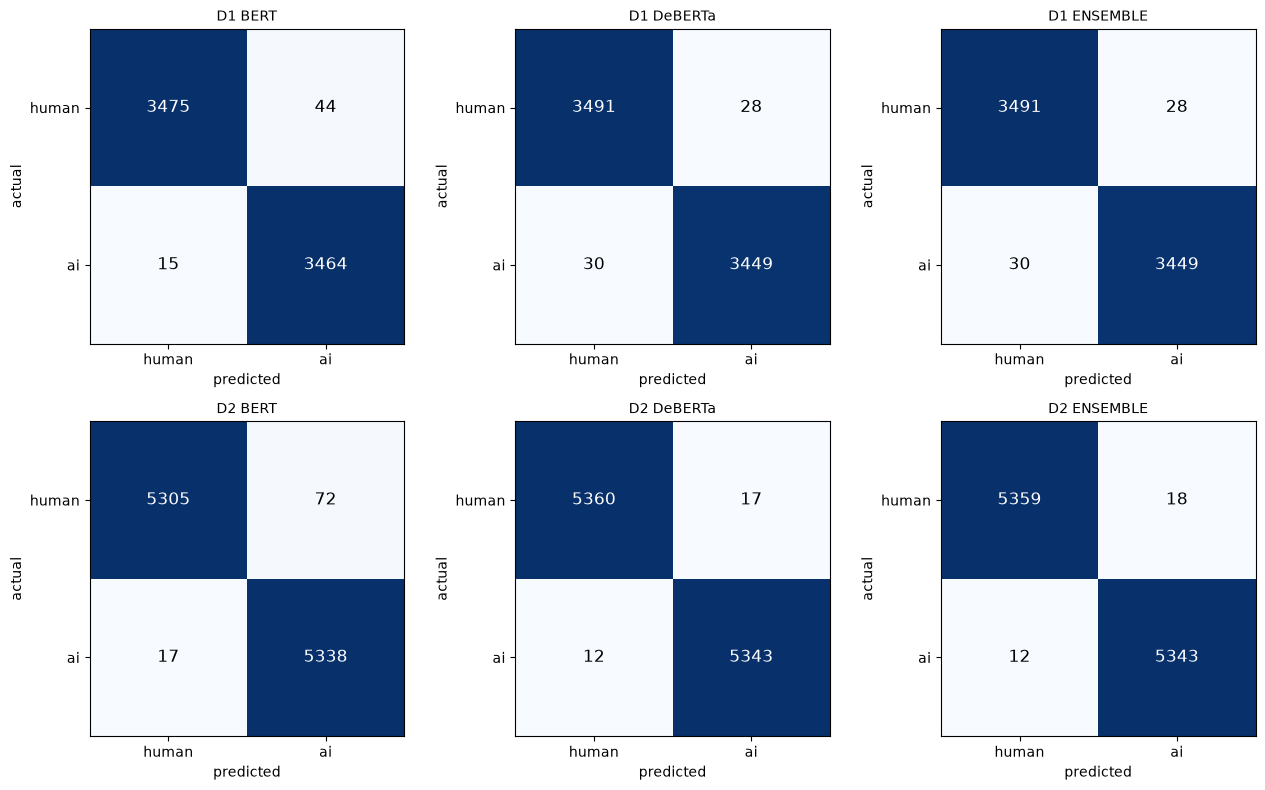

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
panels = [
    ('D1 BERT', TRANSFORMER_RESULTS[('D1','BERT')]['confusion']),
    ('D1 DeBERTa', TRANSFORMER_RESULTS[('D1','DeBERTa')]['confusion']),
    ('D1 ENSEMBLE', ENSEMBLE_RESULTS['D1']['confusion']),
    ('D2 BERT', TRANSFORMER_RESULTS[('D2','BERT')]['confusion']),
    ('D2 DeBERTa', TRANSFORMER_RESULTS[('D2','DeBERTa')]['confusion']),
    ('D2 ENSEMBLE', ENSEMBLE_RESULTS['D2']['confusion']),
]
for ax, (title, cm) in zip(axes.flat, panels):
    cm = np.array(cm)
    ax.imshow(cm, cmap='Blues')
    for a in range(2):
        for b in range(2):
            ax.text(b, a, str(cm[a,b]), ha='center', va='center',
                    color='w' if cm[a,b] > cm.max()/2 else 'k', fontsize=12)
    ax.set_xticks([0,1]); ax.set_xticklabels(['human','ai'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['human','ai'])
    ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title(title, fontsize=10)
plt.tight_layout()
plt.savefig(FIG / 'confusion_matrices_demo.png', dpi=150)
plt.show()

## Section 6 -- Table 1: full 32-configuration sweep**Only 4 of these 32 rows (the winning configurations) were computed live above.**The other 28 could not be, because their model weights were not saved (32 fullcheckpoints would be roughly 18 GB; only the winners were kept). Those 28 numbersare genuine results from the original ~9-hour training sweep, read here from thesaved result files rather than retrained.

In [7]:
GRID = [(2e-05,16,0.01),(3e-05,16,0.01),(2e-05,32,0.01),(3e-05,32,0.01),
        (2e-05,16,0.1),(3e-05,16,0.1),(2e-05,32,0.1),(3e-05,32,0.1)]

all_sweep = [json.load(open(f)) for f in RESULTS.glob('full_*.json')]
all_sweep = [r for r in all_sweep if 'model' in r and r.get('scale')=='full_balanced' and r.get('seed')==42]

def fmt(v): return '%.4f' % v
rows = []
live_configs = set()
for tag in ('D1','D2'):
    for mk in ('BERT','DeBERTa'):
        best = max([r for r in all_sweep if r['dataset']==tag and r['model']==mk], key=lambda r: r['val']['f1'])
        live_configs.add((tag, mk, best['lr'], best['batch_size'], best['weight_decay']))

for mk in ('BERT','DeBERTa'):
    for lr,bs,wd in GRID:
        row = {'Model': mk, 'Learning Rate': '%.5f'%lr, 'Batch Size': bs, 'Weight Decay': wd}
        for tag in ('D1','D2'):
            m = next((r for r in all_sweep if r['dataset']==tag and r['model']==mk and
                     r['lr']==lr and r['batch_size']==bs and r['weight_decay']==wd), None)
            is_live = (tag, mk, lr, bs, wd) in live_configs
            for col, k in (('Acc','accuracy'),('Prec','precision'),('Rec','recall'),('F1','f1')):
                row['%s %s'%(tag,col)] = fmt(m['test'][k]) if m else ''
            row['%s source'%tag] = 'LIVE' if is_live else 'from sweep'
        rows.append(row)

erow = {'Model':'ENSEMBLE','Learning Rate':'','Batch Size':'','Weight Decay':''}
for tag in ('D1','D2'):
    e = ENSEMBLE_RESULTS[tag]
    for col,k in (('Acc','accuracy'),('Prec','precision'),('Rec','recall'),('F1','f1')):
        erow['%s %s'%(tag,col)] = fmt(e[k])
    erow['%s source'%tag] = 'LIVE'
rows.append(erow)

TABLE1 = pd.DataFrame(rows)
TABLE1.to_csv(OUT / 'table1_demo.csv', index=False)
pd.set_option('display.width', 220, 'display.max_columns', 20)
display(TABLE1)

,Model,Learning Rate,Batch Size,Weight Decay,D1 Acc,D1 Prec,D1 Rec,D1 F1,D1 source,D2 Acc,D2 Prec,D2 Rec,D2 F1,D2 source
0,BERT,0.00002,16,0.01,0.9920,0.9920,0.9920,0.9920,from sweep,0.9910,0.9911,0.9910,0.9910,from sweep
1,BERT,0.00003,16,0.01,0.9954,0.9954,0.9954,0.9954,from sweep,0.9940,0.9941,0.9940,0.9940,from sweep
2,BERT,0.00002,32,0.01,0.9936,0.9936,0.9936,0.9936,from sweep,0.9944,0.9944,0.9944,0.9944,from sweep
3,BERT,0.00003,32,0.01,0.9919,0.9919,0.9919,0.9919,from sweep,0.9929,0.9930,0.9929,0.9929,from sweep
4,BERT,0.00002,16,0.1,0.9869,0.9870,0.9869,0.9869,from sweep,0.9916,0.9917,0.9916,0.9916,from sweep
5,BERT,0.00003,16,0.1,0.9901,0.9902,0.9901,0.9901,from sweep,0.9911,0.9912,0.9911,0.9911,from sweep
6,BERT,0.00002,32,0.1,0.9924,0.9924,0.9924,0.9924,from sweep,0.9945,0.9945,0.9945,0.9945,LIVE
7,BERT,0.00003,32,0.1,0.9916,0.9916,0.9916,0.9916,LIVE,0.9933,0.9933,0.9933,0.9933,from sweep
8,DeBERTa,0.00002,16,0.01,0.9953,0.9953,0.9953,0.9953,from sweep,0.9937,0.9937,0.9937,0.9937,from sweep
9,DeBERTa,0.00003,16,0.01,0.9917,0.9917,0.9917,0.9917,from sweep,0.9980,0.9980,0.9980,0.9980,LIVE


## Section 7 -- Table 2: final combined comparisonEvery row here was computed live in this notebook: classical baselines refit inSection 2, BERT/DeBERTa via checkpoint inference in Section 3, ensemble in Section 4.

In [8]:
SPEC_LABEL = {'Naive Bayes':'Naïve Bayes','Logistic Regression':'Logistic Regression','Support Vector Machine':'Support Vector Machine'}
BEST_REP = {'Naive Bayes':'BoW','Logistic Regression':'BoW','Support Vector Machine':'TF-IDF'}
rows2 = []
for name, rep in BEST_REP.items():
    row = {'Model': SPEC_LABEL[name]}
    for tag in ('D1','D2'):
        r = CLASSICAL_RESULTS[(tag, name, rep)]
        for col,k in (('Acc','accuracy'),('Prec','precision'),('Rec','recall'),('F1','f1')):
            row['%s %s'%(tag,col)] = fmt(r[k])
    rows2.append(row)
for mk in ('BERT','DeBERTa'):
    row = {'Model': mk}
    for tag in ('D1','D2'):
        r = TRANSFORMER_RESULTS[(tag,mk)]
        for col,k in (('Acc','accuracy'),('Prec','precision'),('Rec','recall'),('F1','f1')):
            row['%s %s'%(tag,col)] = fmt(r[k])
    rows2.append(row)
row = {'Model':'ENSEMBLE'}
for tag in ('D1','D2'):
    e = ENSEMBLE_RESULTS[tag]
    for col,k in (('Acc','accuracy'),('Prec','precision'),('Rec','recall'),('F1','f1')):
        row['%s %s'%(tag,col)] = fmt(e[k])
rows2.append(row)

TABLE2 = pd.DataFrame(rows2)
TABLE2.to_csv(OUT / 'table2_demo.csv', index=False)
display(TABLE2)

print('\nTotal notebook wall-clock time so far: %.1f minutes' % ((time.time()-t_notebook_start)/60))

,Model,D1 Acc,D1 Prec,D1 Rec,D1 F1,D2 Acc,D2 Prec,D2 Rec,D2 F1
0,Naïve Bayes,0.9591,0.9603,0.9591,0.9591,0.8713,0.8715,0.8713,0.8713
1,Logistic Regression,0.9893,0.9893,0.9893,0.9893,0.9551,0.9551,0.9551,0.9551
2,Support Vector Machine,0.9910,0.9911,0.9910,0.9910,0.9449,0.9452,0.9449,0.9449
3,BERT,0.9916,0.9916,0.9916,0.9916,0.9917,0.9918,0.9917,0.9917
4,DeBERTa,0.9917,0.9917,0.9917,0.9917,0.9973,0.9973,0.9973,0.9973
5,ENSEMBLE,0.9917,0.9917,0.9917,0.9917,0.9972,0.9972,0.9972,0.9972



Total notebook wall-clock time so far: 6.9 minutes
